# Basic Setups

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Load and Clean Dataset 

In [2]:
df=pd.read_csv('../data/advertising.csv', skiprows=1, header=None)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       200 non-null    float64
 1   1       200 non-null    float64
 2   2       200 non-null    float64
 3   3       200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [3]:
N=df.shape[0]
X=df.iloc[:,:3].astype(float).to_numpy()
y=df.iloc[:,3].astype(float).to_numpy().reshape(-1,1)

# Mean Normalization

In [4]:
def mean_normalization(X):
    avg=np.mean(X, axis=0)
    max=np.max(X, axis=0)
    min=np.min(X, axis=0)   
    X_coppy=(X-avg)/(max-min)

    # Custom X features again to (200, 4) shape
    return np.hstack((np.ones((N,1)), X_coppy))

X_b=mean_normalization(X)

In [5]:
# Check everything again
print("Shape of X_b:", X_b.shape)
print("First 5 rows of X_b:\n", X_b[:5])
print("y (first 5):\n", y[:5].ravel())

Shape of X_b: (200, 4)
First 5 rows of X_b:
 [[ 1.          0.28088434  0.29306452  0.33989446]
 [ 1.         -0.34677883  0.32330645  0.12793316]
 [ 1.         -0.43910213  0.45637097  0.34077397]
 [ 1.          0.0150744   0.36362903  0.24578716]
 [ 1.          0.11416131 -0.25129032  0.24490765]]
y (first 5):
 [22.1 10.4 12.  16.5 17.9]


# Building functions

In [6]:
def predict(x, theta):
    return x.dot(theta)   

def compute_loss(y_hat, y, m):
    return 1/m * (y_hat-y).T.dot(y_hat-y)

def gradient_compute(x, y_hat, y):
    k=2*(y_hat-y)
    return k.T.dot(x)

def update_theta(theta, gradient, lr):
    return theta - lr*gradient.T

In [7]:
def m_sample_gradient_descent(X_b, y, m=20, n_epochs=100, lr=0.01):
    N=X_b.shape[0]
    thetas = np.random.randn(4,1)
    losses=[]
    for _ in range(n_epochs):
        shuffled_indices = np.array(range(N)) if m in [1, N] else np.random.permutation(N)
        X_b_shuffled = X_b[shuffled_indices]
        y_shuffled = y[shuffled_indices]

        for i in range(0, N, m):
            x=X_b_shuffled[i:i+m]
            y_i=y_shuffled[i:i+m]
            y_hat=predict(x, thetas)
            losses.append(compute_loss(y_hat, y_i, m)[0][0])
            gradient=gradient_compute(x, y_hat, y_i)/m
            thetas=update_theta(thetas, gradient, lr)
    
    plt.plot(losses)
    plt.xlabel('Iteration')
    plt.ylabel('Loss')
    plt.title('Loss over Iterations')
    plt.show()


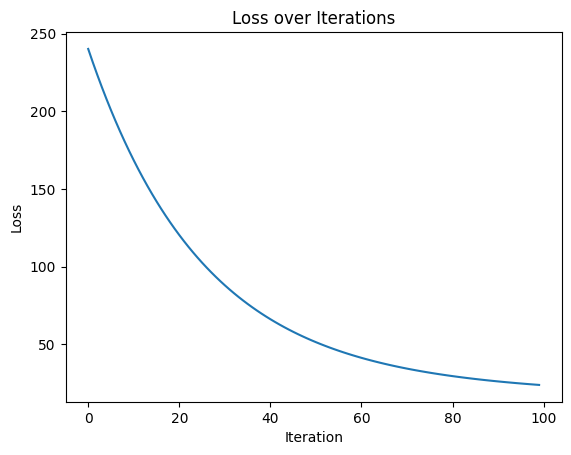

In [9]:
m_sample_gradient_descent(X_b, y, m=N)